In [243]:
from scipy import linalg as la
import numpy as np 
from modules import model_BHZ_2D as bhz
import kwant
import matplotlib.pyplot as plt
from importlib import reload
from modules import functions as fn
from modules import plotting as pl
import pickle as pi
from pathlib import Path
import os,re


# model

In [32]:
reload(bhz)
p = bhz.params
p['Lx'] = 10
p['Ly'] = 10
p['A'] = 1
p['B'] = 1
p['Delta'] = 2
sys = bhz.system_2D_BHZ(p)
ham = sys.finalized().hamiltonian_submatrix()


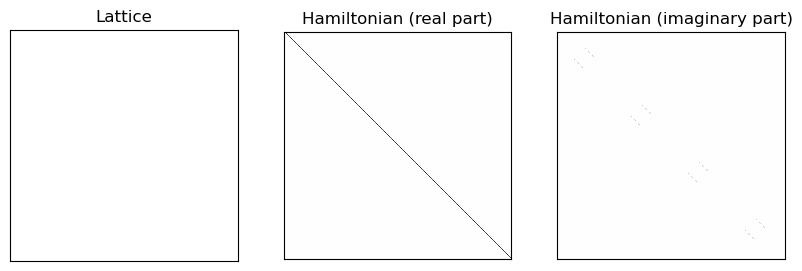

In [33]:

#### plotting ####
fig, ax = plt.subplots(1, 3, figsize=(10, 3))
ax[1].matshow(
    ham.real,
    cmap="bwr",
    clim=(-np.max(np.abs(ham.real)), np.max(np.abs(ham.real))),
)
ax[2].matshow(
    ham.imag,
    cmap="bwr",
    clim=(-np.max(np.abs(ham.real)), np.max(np.abs(ham.real))),
)

for a in ax:
    a.set_xticks([])
    a.set_yticks([])

ax[0].set_title("Lattice")
ax[1].set_title("Hamiltonian (real part)")
ax[2].set_title("Hamiltonian (imaginary part)")

plt.show()

Text(0.5, 1.0, 'Energy Spectrum')

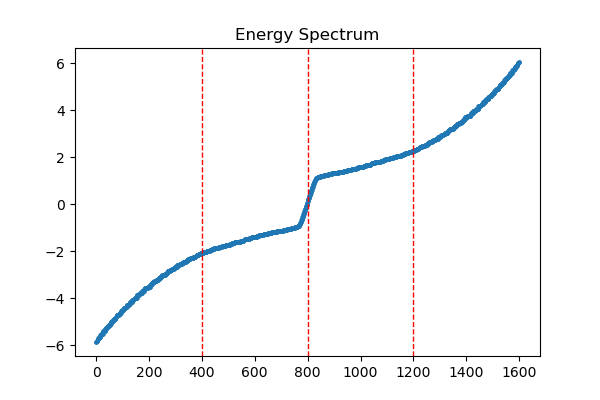

In [36]:
%matplotlib widget

from scipy import linalg as la

e, v = la.eigh(ham)

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(range(len(e)), e, s=5)
ax.axvline(len(e) // 4, color="red", ls="--", linewidth=1)
ax.axvline(len(e) // 2, color="red", ls="--", linewidth=1)
ax.axvline(3 * len(e) // 4, color="red", ls="--", linewidth=1)
ax.set_title("Energy Spectrum")

# phase diagram


In [43]:



reload(bhz)
p = bhz.params
p['Lx'] = 10
p['Ly'] = 10
p['A'] = 1
p['B'] = 1
p['Delta'] =0.5


sys = bhz.system_2D_BHZ(p)
fsys = sys.finalized()


In [44]:
TR = bhz.TR_op(len(fsys.sites))


In [30]:
reload(fn)
pfaf, pfaf_list = fn.spectral_localizer_AII2D(syst=sys,W=0,E0=0,TR=TR)

E0: 0 x0,y0: -0.5 -0.5 kappa: 0.1 W: 0
Averaging over realizations...
Percent: [####################] 100% Done...
Realization Pfaffian: -1.0
Pfaffian sign: -1.0


In [85]:


reload(fn)
reload(bhz)
p = bhz.params
p['Lx'] = 10
p['Ly'] = 10
p['A'] = 1
p['B'] = 1
p['Delta'] = 2

kappa_range = np.linspace(0,1.5,50)
E_range = np.linspace(-2.5,2.5,50)
sys,_ = bhz.system_2D_BHZ(Lx=10,Ly=10,params=p)
fsys = sys.finalized()

p_spec = fn.params.copy()
E_kap_dict = {}
E_kap_dict_reals = {}

for E in [0]:   
    E_kap_dict[E] = []
    E_kap_dict_reals[E] = []

    for kap in kappa_range:
        p_spec['kappa'] = kap
        locgap, locgap_list = fn.spectral_localizer_AII2D(syst=sys,W=0,E0=E,TR=TR,compute_inv=False,compute_localgap=True,p=p_spec)
        E_kap_dict[E].append(locgap)
        E_kap_dict_reals[E].append(locgap_list)

E0: 0 x0,y0: -0.5 -0.5 kappa: 0.0 W: 0
Averaging over realizations...
Percent: [####################] 100% Done...
Local gap realization: [0.03579746]
Time: 0.3306370680220425
Local gap: 0.03579746345796445
E0: 0 x0,y0: -0.5 -0.5 kappa: 0.030612244897959183 W: 0
Averaging over realizations...
Percent: [####################] 100% Done...
Local gap realization: [0.27440925]
Time: 0.3855516859330237
Local gap: 0.2744092477564191
E0: 0 x0,y0: -0.5 -0.5 kappa: 0.061224489795918366 W: 0
Averaging over realizations...
Percent: [####################] 100% Done...
Local gap realization: [0.552461]
Time: 0.41227237740531564
Local gap: 0.5524609973921524


KeyboardInterrupt: 

In [72]:
locgap_matrix = np.zeros((len(E_range),len(kappa_range)))

for i,E in enumerate(E_range):
    elem = [elems[0] for elems in  E_kap_dict[E]]
    locgap_matrix[i,:] = elem

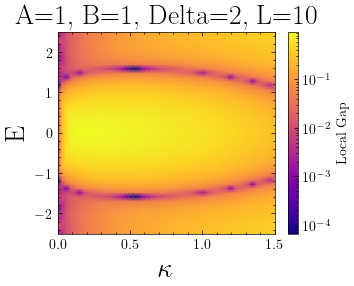

In [73]:
reload(pl)
pl.map_kappaE_locgap(kappa_range,E_range,np.abs(locgap_matrix),title='A=1, B=1, Delta=2, L=10')

In [74]:
pi.dump(E_kap_dict,open('locgap_kappaEmap_0-1.5','wb'))

# conductance

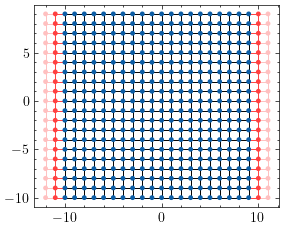

In [280]:
reload(bhz)
p = bhz.params

p['A'] = 1
p['B'] = 1
p['Delta'] = 1
p['W'] = 0
p['mu_leads'] = 0

syst,leadp,leadm = bhz.BHZ_with_leads(Lx=10,Ly=10,params=p)


kwant.plot(syst);

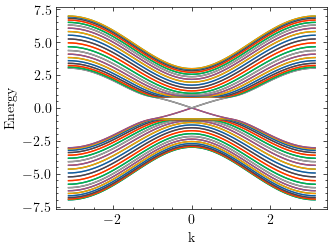

In [281]:
kwant.plotter.bands(leadp);

In [217]:
import kwant 

kwant_op = kwant.operator.Density(syst, sum=False)
local_dos = kwant.kpm.SpectralDensity(syst, operator = kwant_op,num_moments=300,rng=0)



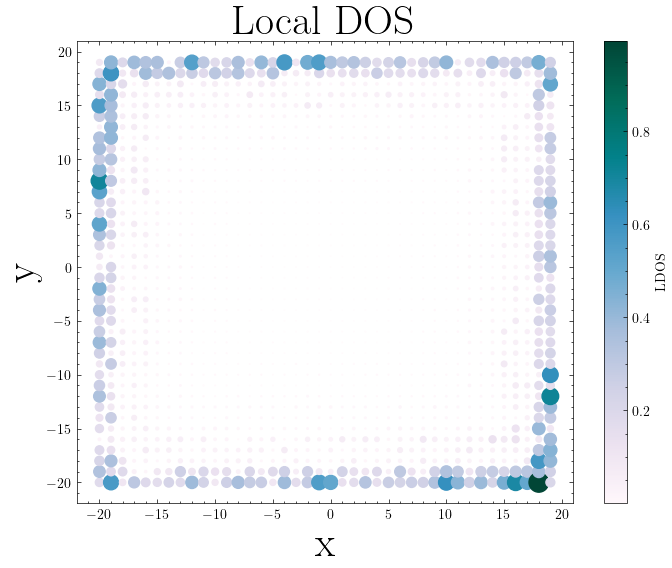

In [218]:
sites = np.array([site.pos for site in syst.sites])
# Compute the local density of states at zero energy
ldos_real_space = np.abs(local_dos(0.1)).real

plt.figure(figsize=(8,6))
# plt.scatter(sites[:, 0], sites[:, 1], color='black',sizes=1)
# plt.scatter(sites[:, 0], sites[:, 1], color='black',s=0.1)

plt.scatter(sites[:, 0], sites[:, 1], c=ldos_real_space, cmap='PuBuGn', sizes=200*ldos_real_space)


plt.colorbar(label='LDOS')
plt.title(r'Local DOS',fontsize=30)
plt.xlabel('x',fontsize=30)
plt.ylabel('y',fontsize=30)
plt.show()

In [233]:
reload(fn)
reload(bhz)
p = bhz.params

p['A'] = 1
p['B'] = 1
p['Delta'] = 2
p['W'] = 0
p['mu_leads'] = 1.9
fn.average_conductance_W(0.01,Wr=[2],Lx=10,Ly=10,params=p)

Averaging over realizations...
Percent: [--------------------] 2.0% Disordered system with strength 2 with seed 0
Percent: [#-------------------] 4.0% Disordered system with strength 2 with seed 1
Percent: [#-------------------] 6.0% Disordered system with strength 2 with seed 2
Percent: [##------------------] 8.0% Disordered system with strength 2 with seed 3
Percent: [##------------------] 10.0% Disordered system with strength 2 with seed 4
Percent: [##------------------] 12.0% Disordered system with strength 2 with seed 5
Percent: [###-----------------] 14.0% Disordered system with strength 2 with seed 6
Percent: [###-----------------] 16.0% Disordered system with strength 2 with seed 7
Percent: [####----------------] 18.0% Disordered system with strength 2 with seed 8
Percent: [####----------------] 20.0% Disordered system with strength 2 with seed 9
Percent: [####----------------] 22.0% Disordered system with strength 2 with seed 10
Percent: [#####---------------] 24.0% Disordered

([1.9999983475524368],
 [[1.9999985595894645,
   1.9999981370608,
   1.9999989694715035,
   1.999996307073804,
   1.999999961508429,
   1.9999915661838905,
   1.9999956142891135,
   1.9999997854290046,
   1.9999975749249252,
   1.9999998130985805,
   1.9999998098873215,
   1.9999992176013983,
   1.9999992666283337,
   1.999997694129233,
   1.9999994864769362,
   1.9999982635880558,
   1.9999983208791714,
   1.9999983097385041,
   1.9999989622805847,
   1.999998497098846,
   1.9999981799258715,
   1.99999999700835,
   1.9999959466132196,
   1.9999958686781123,
   1.999997842363574,
   1.9999971381344666,
   1.9999993860514176,
   1.9999995760619103,
   1.9999985841036434,
   1.9999947998469694,
   1.9999997503981888,
   1.9999980900973526,
   1.999999121533169,
   1.9999993169945363,
   1.9999976578330154,
   1.999999736949073,
   1.9999998775017158,
   1.9999993150639483,
   1.999999941508165,
   1.9999986609777987,
   1.9999995296301352,
   1.9999984747162929,
   1.9999990024654877,
 

## phase diagram

In [282]:

folder =  Path.cwd() / "data"/"conductance" /"phase-diag" / "range-D-2-10" 


dic = []
def extract_E_value(filename):
    match = re.search(r'_Delta_([-+]?[0-9]*\.?[0-9]+)', filename)
    if match:
        return float(match.group(1))
    return float('inf')  # Por si no encuentra el valor

print(sorted(os.listdir(folder), key=extract_E_value))

for file in sorted(os.listdir(folder), key=extract_E_value):
    dic.append(pi.load(open(os.path.join(folder, file), 'rb')))



['G_W_0.0_12.0_L_5_A1_B1_Delta_-2.0', 'G_W_0.0_12.0_L_5_A1_B1_Delta_-1.7551020408163265', 'G_W_0.0_12.0_L_5_A1_B1_Delta_-1.510204081632653', 'G_W_0.0_12.0_L_5_A1_B1_Delta_-1.2653061224489797', 'G_W_0.0_12.0_L_5_A1_B1_Delta_-1.0204081632653061', 'G_W_0.0_12.0_L_5_A1_B1_Delta_-0.7755102040816326', 'G_W_0.0_12.0_L_5_A1_B1_Delta_-0.5306122448979593', 'G_W_0.0_12.0_L_5_A1_B1_Delta_-0.2857142857142858', 'G_W_0.0_12.0_L_5_A1_B1_Delta_-0.04081632653061229', 'G_W_0.0_12.0_L_5_A1_B1_Delta_0.204081632653061', 'G_W_0.0_12.0_L_5_A1_B1_Delta_0.44897959183673475', 'G_W_0.0_12.0_L_5_A1_B1_Delta_0.693877551020408', 'G_W_0.0_12.0_L_5_A1_B1_Delta_0.9387755102040813', 'G_W_0.0_12.0_L_5_A1_B1_Delta_1.183673469387755', 'G_W_0.0_12.0_L_5_A1_B1_Delta_1.4285714285714284', 'G_W_0.0_12.0_L_5_A1_B1_Delta_1.6734693877551021', 'G_W_0.0_12.0_L_5_A1_B1_Delta_1.9183673469387754', 'G_W_0.0_12.0_L_5_A1_B1_Delta_2.163265306122449', 'G_W_0.0_12.0_L_5_A1_B1_Delta_2.408163265306122', 'G_W_0.0_12.0_L_5_A1_B1_Delta_2.65306122

In [283]:

D_completed = [list(elem.keys())[0] for elem in dic]
g_completed = [list(elem.values())[0] for elem in dic]

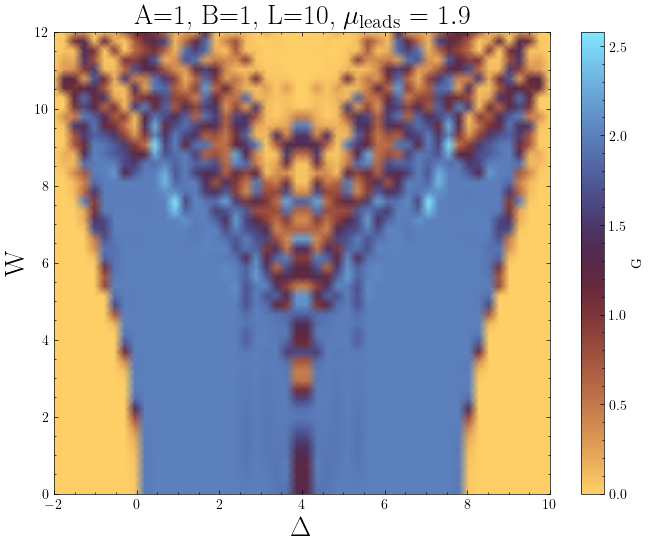

In [284]:
reload(pl)
pl.map_Delta_W_conductance(D_completed,np.linspace(0,12,50),np.array(g_completed).T,title=r'A=1, B=1, L=10, $\mu_{\text{leads}}=1.9$')

In [ ]:

import numpy as np

b=np.linspace(-2,10,50)

E = len(b)
# for elem in b:
#     if elem not in a:
#         b.remove(elem)
# # print(b)
W = []
for i,elem in enumerate(b):
    # print(elem)
    if np.mod(i+1,E)==0:
        print('\n')
        lista = list(b[(i+1)-E:i+1])
        print(" ".join(f'{x}' for x in lista) )
        a = " ".join(f'"{[x]}"' for x in lista)
        W.append(a)

# plots

In [ ]:

folder =  Path.cwd() / "data"/"kappachecks_Delta2_W" /"locgap" / "kappa_0.1" / "z2" 


dic = []
def extract_E_value(filename):
    match = re.search(r'_Delta_([-+]?[0-9]*\.?[0-9]+)', filename)
    if match:
        return float(match.group(1))
    return float('inf')  # Por si no encuentra el valor

print(sorted(os.listdir(folder), key=extract_E_value))

for file in sorted(os.listdir(folder), key=extract_E_value):
    dic.append(pi.load(open(os.path.join(folder, file), 'rb')))



In [ ]:

W_completed = [list(elem.keys())[0] for elem in dic]
y_completed = [list(elem.values())[0] for elem in dic]

In [ ]:
C = ['#648FFF','#DC267F', '#FE6100','#785EF0','#FFB000']

plt.style.use('science')

plt.figure()

plt.plot(W_completed, y_completed)

